In [1]:
import os
import sys
import yaml
sys.path.append(os.path.abspath('.')) # to run files that are away
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB logs

libraries = ["torch", "numpy", "polars"]
modules   = {lib: sys.modules.get(lib) for lib in libraries}

if not modules["torch"]:
    import torch
if not modules["numpy"]:
    import numpy as np
if not modules["polars"]:
    import polars as pl

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from utils import Losses, DimensionalityEstimator


In [ ]:
"""Load the data"""

data_file = f"./ASM_data/1. marathon0_reduced to 1RC + common signals/wafer performance/Spatial property after step 1.csv"
df        = pl.read_csv(data_file, ignore_errors=True)

# X_scaled   = MinMaxScaler().fit_transform(df.values)
# X_tensor   = torch.tensor(X_scaled, dtype=torch.float32)
# dataset    = TensorDataset(X_tensor, X_tensor) # Autoencoder reconstructs the input

# num_time_series = len(dataset)
# train_size = int(data_split * num_time_series)
# valid_size = num_time_series - train_size
# train_dataset, val_dataset = random_split(dataset, [train_size, valid_size])

# print(f"Dataset shape: {X_scaled.shape}, so {X_scaled.shape[1]} features")
# data_dimensionality= DimensionalityEstimator.estimate_dataset_dimensionality(X_scaled)
# print(f"Recommended latent layer size: {data_dimensionality:.1f}")


In [26]:
# df.head(10)

means = df.mean()
cols_to_remove = []
for col_name in df.columns:
    if means[col_name][0] == 0:
        cols_to_remove.append(col_name)
df_filtered = df.drop(cols_to_remove)

print(df.shape)
print(df_filtered.shape)



(617703, 138)
(617703, 91)


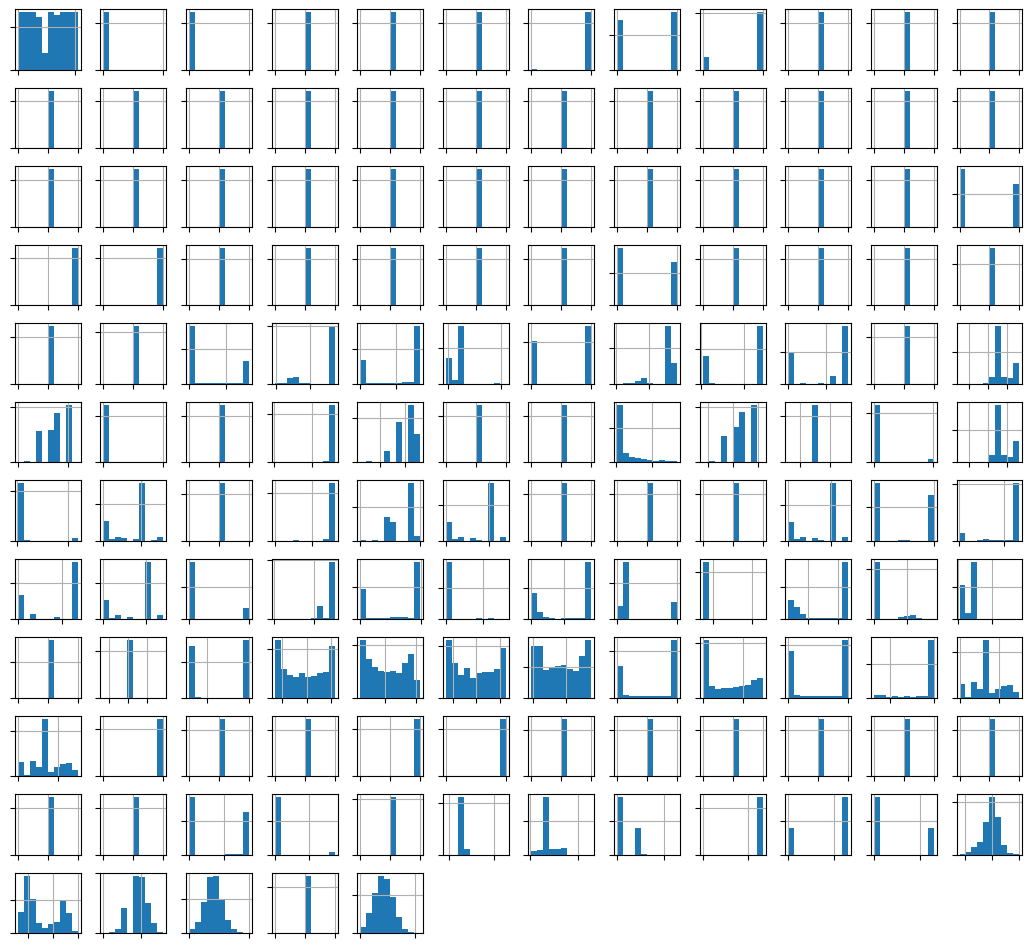

In [36]:
# df.to_pandas().hist(figsize=(13, 12))
# plt.show()

pdf = df.to_pandas()
axes = pdf.hist(figsize=(13, 12))

for ax in axes.flatten():
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# plt.tight_layout()
plt.show()


In [29]:
# df_numeric = df_filtered.select(pl.col(pl.Float64)) 
# data_dimensionality= DimensionalityEstimator.estimate_dataset_dimensionality(df_numeric)
# print(f"Recommended latent layer size: {data_dimensionality:.1f}")
# print(df_numeric.shape)

print(df_filtered.describe())



shape: (9, 92)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ Process   ┆ Run #     ┆ Common    ┆ … ┆ RC3       ┆ RC3       ┆ RC3       ┆ RC3 sign │
│ ---       ┆ Time      ┆ ---       ┆ signal_0  ┆   ┆ signal_10 ┆ signal_11 ┆ signal_12 ┆ al_14    │
│ str       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ str       ┆           ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 617703    ┆ 617703.0  ┆ 617703.0  ┆ … ┆ 617703.0  ┆ 617703.0  ┆ 617703.0  ┆ 617703.0 │
│ null_coun ┆ 0         ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ null      ┆ 105.65703 ┆ 0.000011  ┆ … ┆ 187.77714 ┆ 149.95993 